In [1]:
!pip install albumentations -q

import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                      BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import albumentations as A
import kagglehub

# ── Training Dataset (Big) ─────────────────────────
path_big = kagglehub.dataset_download("zaidpy/oral-cancer-dataset")
print(f"✅ Big dataset: {path_big}")

# ── Test Dataset (Small) ───────────────────────────
path_small = kagglehub.dataset_download(
    "shivam17299/oral-cancer-lips-and-tongue-images")
print(f"✅ Small dataset: {path_small}")

100%|██████████| 315M/315M [00:01<00:00, 170MB/s]

Extracting files...


✅ Big dataset: /root/.cache/kagglehub/datasets/zaidpy/oral-cancer-dataset/versions/2


100%|██████████| 27.7M/27.7M [00:00<00:00, 149MB/s] 

Extracting files...


✅ Small dataset: /root/.cache/kagglehub/datasets/shivam17299/oral-cancer-lips-and-tongue-images/versions/1


In [3]:
datasets = [
    {
        'root': os.path.join(path_big, 'Oral Cancer/Oral Cancer Dataset'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    },
    {
        'root': os.path.join(path_big, 'Oral cancer Dataset 2.0/OC Dataset kaggle new'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    }
]

filepaths, labels = [], []

for ds in datasets:
    for folder_name, label in ds['subfolders'].items():
        folder_path = os.path.join(ds['root'], folder_name)
        if os.path.exists(folder_path):
            images = [f for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"✅ {len(images)} images — {label}  [{folder_path}]")
            for img in images:
                filepaths.append(os.path.join(folder_path, img))
                labels.append(label)
        else:
            print(f"❌ Not found: {folder_path}")
df_train = pd.DataFrame({'filename': filepaths, 'label': labels})
df_train = df_train.drop_duplicates(subset='filename').reset_index(drop=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Before balancing:")
print(df_train['label'].value_counts())

# ── Balance: randomly remove 300 cancer → 700/700 ─
cancer_df    = df_train[df_train['label'] == 'cancer']
noncancer_df = df_train[df_train['label'] == 'non_cancer']

cancer_df_balanced = cancer_df.sample(n=700, random_state=42)

df_train = pd.concat([cancer_df_balanced, noncancer_df]).reset_index(drop=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 After balancing (700/700):")
print(df_train['label'].value_counts())
print(f"Total: {len(df_train)}")

✅ 500 images — cancer  [/root/.cache/kagglehub/datasets/zaidpy/oral-cancer-dataset/versions/2/Oral Cancer/Oral Cancer Dataset/CANCER]
✅ 250 images — non_cancer  [/root/.cache/kagglehub/datasets/zaidpy/oral-cancer-dataset/versions/2/Oral Cancer/Oral Cancer Dataset/NON CANCER]
✅ 500 images — cancer  [/root/.cache/kagglehub/datasets/zaidpy/oral-cancer-dataset/versions/2/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER]
✅ 450 images — non_cancer  [/root/.cache/kagglehub/datasets/zaidpy/oral-cancer-dataset/versions/2/Oral cancer Dataset 2.0/OC Dataset kaggle new/NON CANCER]

📊 Before balancing:
label
cancer        1000
non_cancer     700
Name: count, dtype: int64

📊 After balancing (700/700):
label
cancer        700
non_cancer    700
Name: count, dtype: int64
Total: 1400


In [4]:
filepaths_test, labels_test = [], []
label_map_small = {'cancer': 'cancer', 'non-cancer': 'non_cancer'}

for folder_name, label in label_map_small.items():
    folder_path = os.path.join(path_small, 'OralCancer', folder_name)
    if os.path.exists(folder_path):
        images = [f for f in os.listdir(folder_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"✅ {len(images)} images — {label}")
        for img in images:
            filepaths_test.append(os.path.join(folder_path, img))
            labels_test.append(label)
    else:
        print(f"❌ Not found: {folder_path}")

df_test = pd.DataFrame({'filename': filepaths_test, 'label': labels_test})
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Total Test Images : {len(df_test)}")
print(df_test['label'].value_counts())

✅ 87 images — cancer
✅ 44 images — non_cancer

📊 Total Test Images : 131
label
cancer        87
non_cancer    44
Name: count, dtype: int64


In [5]:
TARGET_SIZE = 224

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_enhanced, a, b]), cv2.COLOR_LAB2RGB)

def smart_resize(img, target_size=TARGET_SIZE):
    h, w = img.shape[:2]
    min_dim = min(h, w)
    start_h = (h - min_dim) // 2
    start_w = (w - min_dim) // 2
    img_cropped = img[start_h:start_h+min_dim, start_w:start_w+min_dim]
    return cv2.resize(img_cropped, (target_size, target_size))

def sharpen(img):
    gaussian = cv2.GaussianBlur(img, (0, 0), 2.0)
    sharpened = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def preprocess_image(filepath, target_size=TARGET_SIZE, preprocess_fn=None):
    img = cv2.imread(filepath)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = apply_clahe(img)
    img = sharpen(img)
    img = smart_resize(img, target_size)
    img = img.astype('float32')
    if preprocess_fn:
        img = preprocess_fn(img)
    return img

In [6]:
# ── Augmentation Transform (unchanged) ────────────
offline_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=25, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10, p=0.4),
    A.GaussNoise(var_limit=(5, 20), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GridDistortion(num_steps=5,
                     distort_limit=0.2, p=0.2),
])

PREPROCESS_DIR = '/content/preprocessed_densenet'
AUG_DIR        = '/content/augmented_densenet'
BATCH_SIZE     = 32

/tmp/ipykernel_2376/3703920416.py:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),


In [7]:
# ── Step 1: Save Preprocessed Images ──────────────
os.makedirs(f'{PREPROCESS_DIR}/cancer',     exist_ok=True)
os.makedirs(f'{PREPROCESS_DIR}/non_cancer', exist_ok=True)

n_existing = (len(os.listdir(f'{PREPROCESS_DIR}/cancer')) +
              len(os.listdir(f'{PREPROCESS_DIR}/non_cancer')))

if n_existing > 0:
    print(f"✅ Preprocessed images already exist ({n_existing}) — skipping")
else:
    print("Preprocessing and saving to /content/preprocessed_densenet ...")

    for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
        img = cv2.imread(row['filename'])
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = apply_clahe(img)
        img = sharpen(img)
        img = smart_resize(img, TARGET_SIZE)

        label     = row['label']
        fname     = os.path.splitext(os.path.basename(row['filename']))[0]
        save_path = f'{PREPROCESS_DIR}/{label}/{fname}.jpg'

        cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    n_c  = len(os.listdir(f'{PREPROCESS_DIR}/cancer'))
    n_nc = len(os.listdir(f'{PREPROCESS_DIR}/non_cancer'))
    print(f"\n✅ Saved to /content/preprocessed_densenet")
    print(f"   cancer     : {n_c}")
    print(f"   non_cancer : {n_nc}")

os.system("du -sh /content/preprocessed_densenet")

Preprocessing and saving to /content/preprocessed_densenet ...


100%|██████████| 1400/1400 [01:07<00:00, 20.61it/s]


✅ Saved to /content/preprocessed_densenet
   cancer     : 461
   non_cancer : 450


0

In [8]:
# ── Step 2: Train/Val Split ────────────────────────
all_paths, all_labels = [], []

for label in ['cancer', 'non_cancer']:
    folder = f'{PREPROCESS_DIR}/{label}'
    for fname in os.listdir(folder):
        all_paths.append(os.path.join(folder, fname))
        all_labels.append(label)

all_labels_binary = [1 if l == 'cancer' else 0 for l in all_labels]

train_paths, val_paths, y_train_split, y_val_split = train_test_split(
    all_paths, all_labels_binary,
    test_size=0.2,
    random_state=42,
    stratify=all_labels_binary
)

print(f"Train : {len(train_paths)} | Val : {len(val_paths)}")
print(f"Train → Cancer: {sum(np.array(y_train_split)==1)} | "
      f"Non-Cancer: {sum(np.array(y_train_split)==0)}")
print(f"Val   → Cancer: {sum(np.array(y_val_split)==1)} | "
      f"Non-Cancer: {sum(np.array(y_val_split)==0)}")

Train : 728 | Val : 183
Train → Cancer: 368 | Non-Cancer: 360
Val   → Cancer: 93 | Non-Cancer: 90


In [9]:
# ── Step 3: Offline Augment TRAIN only ────────────
os.makedirs(f'{AUG_DIR}/cancer',     exist_ok=True)
os.makedirs(f'{AUG_DIR}/non_cancer', exist_ok=True)

n_existing_aug = (len(os.listdir(f'{AUG_DIR}/cancer')) +
                  len(os.listdir(f'{AUG_DIR}/non_cancer')))

if n_existing_aug > 0:
    print(f"✅ Augmented images already exist ({n_existing_aug}) — skipping")
else:
    N_COPIES = 4   # 1120 originals × 5 = 5600 total
    print(f"Augmenting train set × {N_COPIES} → /content/augmented_densenet ...")
    print(f"Original: {len(train_paths)} → Target: {len(train_paths) * (N_COPIES+1)}")

    for idx, (fpath, label_int) in enumerate(
            tqdm(zip(train_paths, y_train_split),
                 total=len(train_paths))):

        label = 'cancer' if label_int == 1 else 'non_cancer'

        img = cv2.imread(fpath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        fname_base = os.path.splitext(os.path.basename(fpath))[0]

        # Save original copy
        cv2.imwrite(
            f'{AUG_DIR}/{label}/orig_{fname_base}.jpg',
            cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        )

        # Save N augmented copies
        for c in range(N_COPIES):
            augmented = offline_transform(image=img)['image']
            cv2.imwrite(
                f'{AUG_DIR}/{label}/aug{c}_{fname_base}.jpg',
                cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
            )

    n_c  = len(os.listdir(f'{AUG_DIR}/cancer'))
    n_nc = len(os.listdir(f'{AUG_DIR}/non_cancer'))
    print(f"\n✅ Saved to /content/augmented_densenet")
    print(f"   cancer     : {n_c}")
    print(f"   non_cancer : {n_nc}")
    print(f"   total      : {n_c + n_nc}")

os.system("du -sh /content/augmented_densenet")

Augmenting train set × 4 → /content/augmented_densenet ...
Original: 728 → Target: 3640


100%|██████████| 728/728 [00:11<00:00, 61.87it/s]



✅ Saved to /content/augmented_densenet
   cancer     : 1840
   non_cancer : 1800
   total      : 3640


0

In [10]:
# ── Step 4: Load Val Set into RAM ──────────────────
print("Loading val set into RAM...")
X_val, y_val = [], []

for fpath, label_int in tqdm(zip(val_paths, y_val_split),
                              total=len(val_paths)):
    img = cv2.imread(fpath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32')
    img = dense_preprocess(img)   # DenseNet normalisation ✅
    X_val.append(img)
    y_val.append(label_int)

X_val = np.array(X_val)
y_val = np.array(y_val)

print(f"✅ Val shape : {X_val.shape}")
print(f"   Cancer   : {sum(y_val==1)}")
print(f"   NonCancer: {sum(y_val==0)}")

Loading val set into RAM...


100%|██████████| 183/183 [00:00<00:00, 507.30it/s]

✅ Val shape : (183, 224, 224, 3)
   Cancer   : 93
   NonCancer: 90


In [11]:
# ── Step 5: Generators ─────────────────────────────
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=dense_preprocess   # DenseNet normalisation ✅
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    AUG_DIR,
    target_size=(TARGET_SIZE, TARGET_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_cancer', 'cancer'],   # 0=non_cancer, 1=cancer
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\n✅ Train generator ready")
print(f"   Samples : {train_gen.samples}")
print(f"   Batches : {len(train_gen)}")
print(f"   Classes : {train_gen.class_indices}")

print(f"\n✅ Val generator ready")
print(f"   Samples : {len(X_val)}")

Found 3640 images belonging to 2 classes.

✅ Train generator ready
   Samples : 3640
   Batches : 114
   Classes : {'non_cancer': 0, 'cancer': 1}

✅ Val generator ready
   Samples : 183


In [12]:
# ── Step 6: Class Weights ──────────────────────────
n_cancer    = len(os.listdir(f'{AUG_DIR}/cancer'))
n_noncancer = len(os.listdir(f'{AUG_DIR}/non_cancer'))
total_aug   = n_cancer + n_noncancer

class_weight_dict = {
    0: total_aug / (2 * n_noncancer),
    1: total_aug / (2 * n_cancer)
}
print(f"Class weights : {class_weight_dict}")
# Should be near 1.0 / 1.0 since dataset is now balanced ✅

Class weights : {0: 1.011111111111111, 1: 0.9891304347826086}


In [13]:
# ── Build DenseNet-121 ─────────────────────────────
def build_densenet(input_shape=(TARGET_SIZE, TARGET_SIZE, 3)):
    base_model = DenseNet121(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)   # DenseNet features are richer → 256
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)
    return model, base_model

dense_model, dense_base = build_densenet()
print(f"Total params: {dense_model.count_params():,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params: 7,337,025


In [14]:
# ── Callbacks & Compile (identical logic) ─────────
class CombinedMetricCallback(tf.keras.callbacks.Callback):

    def __init__(self, patience=12, model_name='model'):
        super().__init__()
        self.patience     = patience
        self.model_name   = model_name
        self.best_score   = 0
        self.wait         = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        auc      = logs.get('val_auc', 0)
        acc      = logs.get('val_accuracy', 0)
        combined = 0.6 * auc + 0.4 * acc

        print(f"\n  📊 val_auc: {auc:.4f} | val_acc: {acc:.4f} "
              f"| combined: {combined:.4f} (best: {self.best_score:.4f})")

        if combined > self.best_score + 0.001:
            print(f"  ✅ Improved → saving model")
            self.best_score   = combined
            self.wait         = 0
            self.best_weights = self.model.get_weights()
            self.model.save(f'best_{self.model_name}.keras')
        else:
            self.wait += 1
            print(f"  ⏳ No improvement. "
                  f"Patience: {self.wait}/{self.patience}")
            if self.wait >= self.patience:
                print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_weights:
            self.model.set_weights(self.best_weights)
            print(f"\n✅ Best weights restored "
                  f"(combined score: {self.best_score:.4f})")


def get_callbacks(model_name):
    return [
        CombinedMetricCallback(patience=12, model_name=model_name),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1)
    ]


def compile_model(model, lr):
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

In [ ]:
print("="*50)
print("Phase 1 — Training head only (base frozen)")
print("="*50)

compile_model(dense_model, lr=1e-3)

history1 = dense_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('DenseNet121'),
    verbose=1
)

Phase 1 — Training head only (base frozen)
Epoch 1/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.7549 - auc: 0.8388 - loss: 0.4894 - precision: 0.7507 - recall: 0.7567
  📊 val_auc: 0.9667 | val_acc: 0.8603 | combined: 0.9242 (best: 0.0000)
  ✅ Improved → saving model
112/112 ━━━━━━━━━━━━━━━━━━━━ 133s 849ms/step - accuracy: 0.8182 - auc: 0.9066 - loss: 0.3913 - precision: 0.8148 - recall: 0.8203 - val_accuracy: 0.8603 - val_auc: 0.9667 - val_loss: 0.3052 - val_precision: 0.9571 - val_recall: 0.7528 - learning_rate: 0.0010
Epoch 2/20
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.8848 - auc: 0.9570 - loss: 0.2656 - precision: 0.8820 - recall: 0.8817
  📊 val_auc: 0.9716 | val_acc: 0.8994 | combined: 0.9427 (best: 0.9242)
  ✅ Improved → saving model
112/112 ━━━━━━━━━━━━━━━━━━━━ 50s 450ms/step - accuracy: 0.8867 - auc: 0.9578 - loss: 0.2646 - precision: 0.8874 - recall: 0.8839 - val_accuracy: 0.8994 - val_auc: 0.9716 - val_loss: 0.2148 - val_precision: 0.8901 - val_r

In [ ]:
print("="*50)
print("Phase 2 — Fine tuning top 30 layers")
print("="*50)

# DenseNet has more layers than EfficientNetB0 → unfreeze top 30
dense_base.trainable = True
for layer in dense_base.layers[:-30]:
    layer.trainable = False

compile_model(dense_model, lr=1e-5)

history2 = dense_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('DenseNet121'),
    verbose=1
)

Phase 2 — Fine tuning top 30 layers
Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step - accuracy: 0.9280 - auc: 0.9840 - loss: 0.1636 - precision: 0.9123 - recall: 0.9470
  📊 val_auc: 0.9793 | val_acc: 0.9274 | combined: 0.9586 (best: 0.0000)
  ✅ Improved → saving model
112/112 ━━━━━━━━━━━━━━━━━━━━ 126s 811ms/step - accuracy: 0.9309 - auc: 0.9852 - loss: 0.1574 - precision: 0.9125 - recall: 0.9521 - val_accuracy: 0.9274 - val_auc: 0.9793 - val_loss: 0.2036 - val_precision: 0.9419 - val_recall: 0.9101 - learning_rate: 1.0000e-05
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9409 - auc: 0.9886 - loss: 0.1393 - precision: 0.9258 - recall: 0.9580
  📊 val_auc: 0.9792 | val_acc: 0.9274 | combined: 0.9584 (best: 0.9586)
  ⏳ No improvement. Patience: 1/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 49s 434ms/step - accuracy: 0.9424 - auc: 0.9888 - loss: 0.1378 - precision: 0.9280 - recall: 0.9583 - val_accuracy: 0.9274 - val_auc: 0.9792 - val_loss: 0.2055 - val_precision: 0.9419 - v

In [ ]:
# ── Preprocess Test Set ────────────────────────────
print("Preprocessing test images...")
X_test, y_test, test_paths = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    img = preprocess_image(row['filename'], preprocess_fn=dense_preprocess)
    if img is not None:
        X_test.append(img)
        y_test.append(1 if row['label'] == 'cancer' else 0)
        test_paths.append(row['filename'])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"✅ Test shape   : {X_test.shape}")
print(f"Cancer          : {sum(y_test==1)}")
print(f"Non-Cancer      : {sum(y_test==0)}")

Preprocessing test images...


100%|██████████| 131/131 [00:05<00:00, 23.50it/s]

✅ Test shape   : (131, 224, 224, 3)
Cancer          : 87
Non-Cancer      : 44


5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 4s/step

AUC Score         : 0.8685
Optimal Threshold : 0.8980

── Default Threshold (0.50) ──
              precision    recall  f1-score   support

  Non-Cancer       0.79      0.59      0.68        44
      Cancer       0.82      0.92      0.86        87

    accuracy                           0.81       131
   macro avg       0.80      0.76      0.77       131
weighted avg       0.81      0.81      0.80       131


── Optimal Threshold (0.90) ──
              precision    recall  f1-score   support

  Non-Cancer       0.72      0.82      0.77        44
      Cancer       0.90      0.84      0.87        87

    accuracy                           0.83       131
   macro avg       0.81      0.83      0.82       131
weighted avg       0.84      0.83      0.83       131



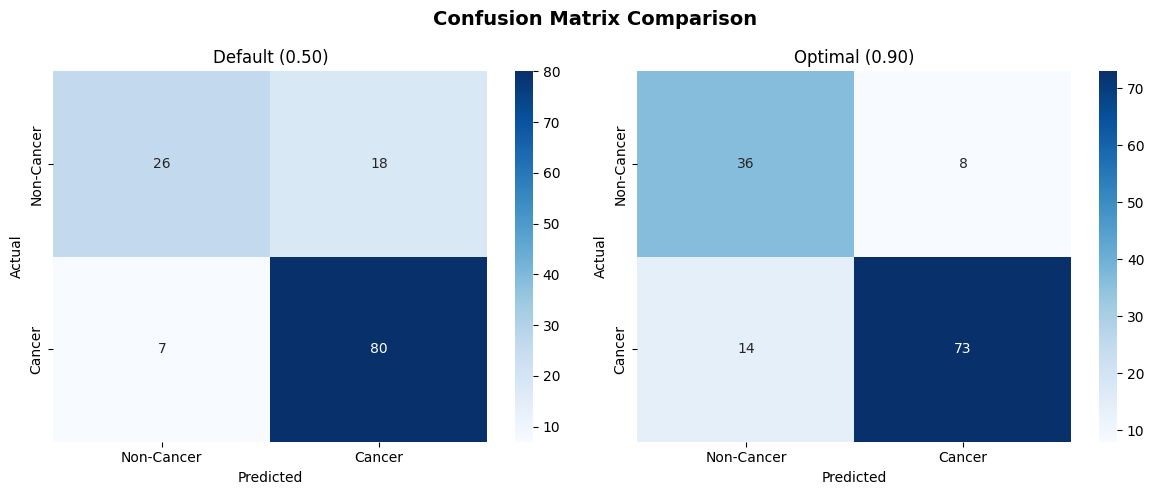

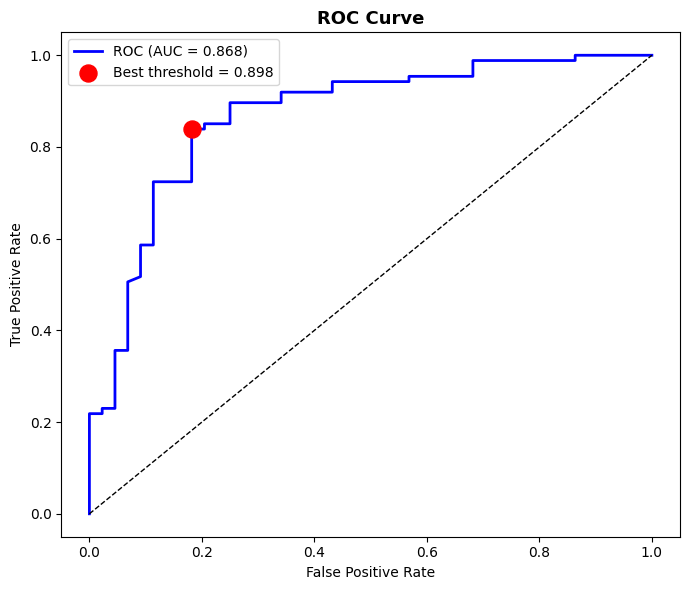

In [ ]:
# ── Load Best Model & Evaluate on Test Set ─────────
dense_model = tf.keras.models.load_model(
    'best_DenseNet121.keras',
    custom_objects={'CombinedMetricCallback': CombinedMetricCallback}
)

y_pred_prob = dense_model.predict(X_test, verbose=1).flatten()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]

y_pred_default = (y_pred_prob >= 0.50).astype(int)
y_pred_optimal = (y_pred_prob >= best_thresh).astype(int)

print(f"\nAUC Score         : {auc_score:.4f}")
print(f"Optimal Threshold : {best_thresh:.4f}")

for preds, label in [
    (y_pred_default, 'Default Threshold (0.50)'),
    (y_pred_optimal, f'Optimal Threshold ({best_thresh:.2f})')
]:
    print(f"\n── {label} ──")
    print(classification_report(y_test, preds,
          target_names=['Non-Cancer', 'Cancer']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(
    axes,
    [y_pred_default, y_pred_optimal],
    ['Default (0.50)', f'Optimal ({best_thresh:.2f})']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Cancer', 'Cancer'],
                yticklabels=['Non-Cancer', 'Cancer'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrix Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC (AUC = {auc_score:.3f})')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red',
            s=150, zorder=5,
            label=f'Best threshold = {best_thresh:.3f}')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Val Set Evaluation (same split reconstruction) ─
all_paths_recon, all_labels_recon = [], []

for label in ['cancer', 'non_cancer']:
    folder = f'{PREPROCESS_DIR}/{label}'
    for fname in os.listdir(folder):
        all_paths_recon.append(os.path.join(folder, fname))
        all_labels_recon.append(1 if label == 'cancer' else 0)

_, val_paths_r, _, y_val_r = train_test_split(
    all_paths_recon, all_labels_recon,
    test_size=0.2, random_state=42,
    stratify=all_labels_recon
)

print("Loading val set for CSV export...")
X_val_f, y_val_f, val_paths_f = [], [], []

for fpath, label_int in tqdm(zip(val_paths_r, y_val_r), total=len(val_paths_r)):
    img = cv2.imread(fpath)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32')
    img = dense_preprocess(img)
    X_val_f.append(img)
    y_val_f.append(label_int)
    val_paths_f.append(fpath)

X_val_f = np.array(X_val_f)
y_val_f = np.array(y_val_f)

y_val_prob = dense_model.predict(X_val_f, batch_size=BATCH_SIZE, verbose=1).flatten()
fpr_v, tpr_v, thresh_v = roc_curve(y_val_f, y_val_prob)
auc_v    = roc_auc_score(y_val_f, y_val_prob)
best_v   = np.argmax(tpr_v - fpr_v)
thresh_v_best = thresh_v[best_v]

y_pred_def_v = (y_val_prob >= 0.50).astype(int)
y_pred_opt_v = (y_val_prob >= thresh_v_best).astype(int)

print(f"\n✅ Val AUC: {auc_v:.4f} | Optimal threshold: {thresh_v_best:.4f}")

results_df = pd.DataFrame({
    'filepath'         : val_paths_f,
    'filename'         : [os.path.basename(f) for f in val_paths_f],
    'actual'           : ['cancer' if y==1 else 'non_cancer' for y in y_val_f],
    'predicted_default': ['cancer' if y==1 else 'non_cancer' for y in y_pred_def_v],
    'predicted_optimal': ['cancer' if y==1 else 'non_cancer' for y in y_pred_opt_v],
    'cancer_prob'      : np.round(y_val_prob, 4),
    'correct_default'  : y_val_f == y_pred_def_v,
    'correct_optimal'  : y_val_f == y_pred_opt_v,
    'result'           : ['✅ CORRECT' if c else '❌ WRONG'
                          for c in (y_val_f == y_pred_opt_v)]
})

results_df.to_csv('/content/densenet_val_predictions.csv', index=False)
print("✅ Saved → /content/densenet_val_predictions.csv")

total   = len(results_df)
correct = results_df['correct_optimal'].sum()
wrong   = total - correct
cancer_df_r    = results_df[results_df['actual'] == 'cancer']
noncancer_df_r = results_df[results_df['actual'] == 'non_cancer']

print(f"\n{'='*45}")
print(f"      VAL PREDICTION COUNT SUMMARY")
print(f"{'='*45}")
print(f"  Total Images    : {total}")
print(f"  ✅ Correct       : {correct}  ({correct/total*100:.1f}%)")
print(f"  ❌ Wrong         : {wrong}   ({wrong/total*100:.1f}%)")
print(f"  Cancer     total : {len(cancer_df_r)}")
print(f"    ✅ Correct     : {cancer_df_r['correct_optimal'].sum()}")
print(f"    ❌ Wrong       : {len(cancer_df_r) - cancer_df_r['correct_optimal'].sum()}")
print(f"  Non-Cancer total : {len(noncancer_df_r)}")
print(f"    ✅ Correct     : {noncancer_df_r['correct_optimal'].sum()}")
print(f"    ❌ Wrong       : {len(noncancer_df_r) - noncancer_df_r['correct_optimal'].sum()}")
print(f"{'='*45}")

Loading val set for CSV export...


100%|██████████| 179/179 [00:00<00:00, 777.25it/s]


6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step

✅ Val AUC: 0.9809 | Optimal threshold: 0.2779
✅ Saved → /content/densenet_val_predictions.csv

      VAL PREDICTION COUNT SUMMARY
  Total Images    : 179
  ✅ Correct       : 169  (94.4%)
  ❌ Wrong         : 10   (5.6%)
  Cancer     total : 89
    ✅ Correct     : 86
    ❌ Wrong       : 3
  Non-Cancer total : 90
    ✅ Correct     : 83
    ❌ Wrong       : 7
